
 # Wide-Net Occlusion Recovery
================================================================
### 1. Relaxed Spatial Filtering (Prevents background drift)
### 2. Safe MAD Outlier Rejection (Handles zero-motion cases)
### 3. Median Flow Translation (Stable, jitter-free movement)
### 4. Mild Scale Updates (Restricted to safe 2% changes)
### 5. WIDE-NET TEMPLATE RECOVERY (Solves Total Occlusion!)
### 6. Performance Evaluation Engine (Multi-Sequence Batch)


Starting Final Optimized Evaluation with Wide-Net Recovery...

--- Processing OTB Sequence: Dog ---
[Dog] Mean IoU: 0.5050 | Precision: 100.0% | Fail Rate: 0.0%

--- Processing OTB Sequence: MountainBike ---
[MountainBike] Mean IoU: 0.7416 | Precision: 100.0% | Fail Rate: 0.0%

--- Processing OTB Sequence: Jogging ---
[Jogging] Mean IoU: 0.7040 | Precision: 90.5% | Fail Rate: 0.3%

--- Processing OTB Sequence: Car4 ---
[Car4] Mean IoU: 0.8616 | Precision: 100.0% | Fail Rate: 0.0%

--- Processing OTB Sequence: Skater ---
[Skater] Mean IoU: 0.5671 | Precision: 100.0% | Fail Rate: 0.0%


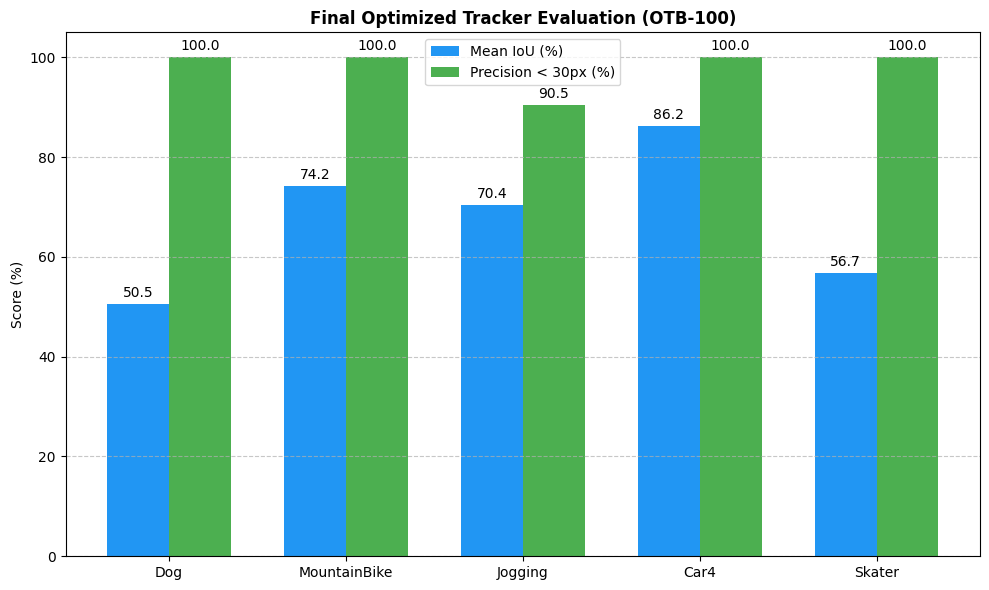

In [1]:
import cv2
import numpy as np
import csv
import os
import glob
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

# ─────────────────────────────────────────────
# PERFORMANCE EVALUATION ENGINE
# ─────────────────────────────────────────────
def load_otb_gt(gt_path: str) -> dict:
    gt_data = {}
    if not os.path.exists(gt_path): return gt_data
    with open(gt_path, "r") as f:
        for idx, line in enumerate(f.readlines()):
            line = line.replace('\t', ',').strip()
            if not line: continue
            parts = [float(p) for p in line.split(',') if p.strip()]
            if len(parts) >= 4:
                x, y, w, h = parts[:4]
                gt_data[idx + 1] = [x, y, x + w, y + h]
    return gt_data

@dataclass
class TrackingMetrics:
    iou_scores: list = field(default_factory=list)
    precision_scores: list = field(default_factory=list)
    failure_frames: int = 0
    total_frames: int = 0
    threshold_px: float = 30.0 

    def update(self, pred_bbox, gt_bbox=None):
        self.total_frames += 1
        if pred_bbox is None:
            self.failure_frames += 1
            self.iou_scores.append(0.0) 
            return
        if gt_bbox is None: return

        iou = self._compute_iou(pred_bbox, gt_bbox)
        self.iou_scores.append(iou)

        pc = self._centre(pred_bbox)
        gc = self._centre(gt_bbox)
        dist = np.linalg.norm(np.array(pc) - np.array(gc))
        self.precision_scores.append(dist <= self.threshold_px)

    @staticmethod
    def _compute_iou(b1, b2):
        x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
        x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
        inter = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / union if union > 0 else 0.0

    @staticmethod
    def _centre(bbox):
        return ((bbox[0]+bbox[2])//2, (bbox[1]+bbox[3])//2)

    def summary(self):
        return dict(
            mean_iou=round(float(np.mean(self.iou_scores) if self.iou_scores else 0.0), 4),
            precision=round(float(np.mean(self.precision_scores) if self.precision_scores else 0.0), 4),
            failure_rate=round(self.failure_frames / self.total_frames if self.total_frames > 0 else 0.0, 4),
            failure_frames=self.failure_frames,
            total_frames=self.total_frames
        )

    def save_csv(self, path):
        with open(path, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.summary().keys())
            writer.writeheader()
            writer.writerow(self.summary())

# ─────────────────────────────────────────────
# STABLE TRACKER ENGINE WITH WIDE-NET RECOVERY
# ─────────────────────────────────────────────
class ResearchTracker:
    def __init__(self, min_points=4):
        self.min_points = min_points

        self.feature_params = dict(maxCorners=30, qualityLevel=0.03, minDistance=5, blockSize=5)
        self.lk_params = dict(winSize=(21, 21), maxLevel=3, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

        self.state = "TRACKING"
        self.p0 = None
        
        self.cx, self.cy = 0.0, 0.0 
        self.current_w, self.current_h = 0.0, 0.0
        self.init_w, self.init_h = 0.0, 0.0
        
        self.bbox = None
        self.base_template = None 
        self.metrics = TrackingMetrics()

    def initialize_from_gt(self, frame: np.ndarray, gt_bbox: list) -> np.ndarray:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        self.bbox = [int(v) for v in gt_bbox]
        
        self.init_w = float(self.bbox[2] - self.bbox[0])
        self.init_h = float(self.bbox[3] - self.bbox[1])
        self.current_w, self.current_h = self.init_w, self.init_h
        self.cx = self.bbox[0] + self.init_w / 2.0
        self.cy = self.bbox[1] + self.init_h / 2.0

        # Save base template for recovery
        x1, y1, x2, y2 = max(0, self.bbox[0]), max(0, self.bbox[1]), min(gray.shape[1], self.bbox[2]), min(gray.shape[0], self.bbox[3])
        if x2 > x1 and y2 > y1:
            self.base_template = gray[y1:y2, x1:x2].copy()

        mask = np.zeros_like(gray)
        mask[y1:y2, x1:x2] = 255
        self.p0 = cv2.goodFeaturesToTrack(gray, mask=mask, **self.feature_params)

        self.state = "TRACKING" if self.p0 is not None else "LOST"
        return gray

    def _attempt_recovery(self, gray: np.ndarray) -> bool:
        """[UPDATED] Scans a MASSIVE area for the target if optical flow is lost."""
        if self.base_template is None: return False
        
        th, tw = self.base_template.shape
        h, w = gray.shape
        
        # ── EXPANDED SEARCH WINDOW (6x width, 3x height) ──
        sx1 = max(0, int(self.cx - tw * 6))
        sy1 = max(0, int(self.cy - th * 3))
        sx2 = min(w, int(self.cx + tw * 6))
        sy2 = min(h, int(self.cy + th * 3))
        
        search_roi = gray[sy1:sy2, sx1:sx2]
        if search_roi.shape[0] < th or search_roi.shape[1] < tw:
            return False
            
        res = cv2.matchTemplate(search_roi, self.base_template, cv2.TM_CCOEFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        
        # ── RELAXED THRESHOLD (0.45) ──
        if max_val > 0.45: 
            self.cx = sx1 + max_loc[0] + tw / 2.0
            self.cy = sy1 + max_loc[1] + th / 2.0
            
            w_half, h_half = self.current_w / 2.0, self.current_h / 2.0
            self.bbox = [int(self.cx - w_half), int(self.cy - h_half), 
                         int(self.cx + w_half), int(self.cy + h_half)]
            return True
            
        return False

    def track(self, old_gray, frame, gt_bbox=None):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # ── RECOVERY LOGIC ──
        if self.p0 is None or len(self.p0) < self.min_points or self.state == "LOST":
            if self._attempt_recovery(gray):
                self._reinitialize(gray)
                self.state = "TRACKING"
            else:
                self.state = "LOST"
                self.metrics.update(None, gt_bbox)
                self._draw(frame)
                return gray, frame

        # ── 1. Forward-Backward Consistency ──
        p1, st, _ = cv2.calcOpticalFlowPyrLK(old_gray, gray, self.p0, None, **self.lk_params)
        p0_back, _, _ = cv2.calcOpticalFlowPyrLK(gray, old_gray, p1, None, **self.lk_params)

        fb_error = np.linalg.norm(self.p0 - p0_back, axis=2).flatten()
        valid = (st.flatten() == 1) & (fb_error < 2.0)
        
        surv_new = p1[valid].reshape(-1, 2)
        surv_old = self.p0[valid].reshape(-1, 2)

        if len(surv_new) < self.min_points:
            self.state = "LOST"
            self.metrics.update(None, gt_bbox)
            self._draw(frame)
            return gray, frame

        # ── 2. Relaxed Spatial Filtering ──
        margin = 20 
        spatial_good = (surv_new[:,0] >= self.bbox[0] - margin) & \
                       (surv_new[:,0] <= self.bbox[2] + margin) & \
                       (surv_new[:,1] >= self.bbox[1] - margin) & \
                       (surv_new[:,1] <= self.bbox[3] + margin)
        
        surv_new = surv_new[spatial_good]
        surv_old = surv_old[spatial_good]

        if len(surv_new) < self.min_points:
            self.state = "LOST"
            self.metrics.update(None, gt_bbox)
            self._draw(frame)
            return gray, frame

        # ── 3. Safe MAD Outlier Rejection ──
        motion = surv_new - surv_old
        dists = np.linalg.norm(motion, axis=1)
        med = np.median(dists)
        mad = np.median(np.abs(dists - med))
        
        if mad < 1e-3:
            mad_good = np.ones_like(dists, dtype=bool) 
        else:
            mad_good = np.abs(dists - med) < (3.0 * mad)
        
        t_new = surv_new[mad_good]
        t_old = surv_old[mad_good]

        if len(t_new) >= self.min_points:
            # ── 4. Median Flow Translation ──
            dx = np.median(t_new[:, 0] - t_old[:, 0])
            dy = np.median(t_new[:, 1] - t_old[:, 1])
            self.cx += dx
            self.cy += dy

            # ── 5. Mild Scale Estimation ──
            center_new = np.median(t_new, axis=0)
            center_old = np.median(t_old, axis=0)
            dist_new = np.linalg.norm(t_new - center_new, axis=1)
            dist_old = np.linalg.norm(t_old - center_old, axis=1)
            
            valid_scale = dist_old > 2.0 
            if np.any(valid_scale):
                scale_factor = np.median(dist_new[valid_scale] / dist_old[valid_scale])
                scale_factor = np.clip(scale_factor, 0.98, 1.02) 
                self.current_w *= scale_factor
                self.current_h *= scale_factor
            
            self.current_w = np.clip(self.current_w, self.init_w * 0.5, self.init_w * 1.5)
            self.current_h = np.clip(self.current_h, self.init_h * 0.5, self.init_h * 1.5)

            w_half, h_half = self.current_w / 2.0, self.current_h / 2.0
            self.bbox = [
                int(self.cx - w_half), int(self.cy - h_half), 
                int(self.cx + w_half), int(self.cy + h_half)
            ]
            self.state = "TRACKING"
        else:
            self.state = "WEAK_TRACKING"

        self.p0 = t_new.reshape(-1, 1, 2)

        # ── 6. Safe Internal Reinitialization ──
        if len(t_new) < 15:
            self._reinitialize(gray)

        self.metrics.update(self.bbox if self.state != "LOST" else None, gt_bbox)
        self._draw(frame)
        return gray, frame

    def _reinitialize(self, gray):
        h_img, w_img = gray.shape
        pad_x = int(self.current_w * 0.1) 
        pad_y = int(self.current_h * 0.1)
        
        x1, y1 = max(0, self.bbox[0] + pad_x), max(0, self.bbox[1] + pad_y)
        x2, y2 = min(w_img, self.bbox[2] - pad_x), min(h_img, self.bbox[3] - pad_y)
        
        if x2 > x1 and y2 > y1:
            mask = np.zeros_like(gray)
            mask[y1:y2, x1:x2] = 255
            if self.p0 is not None:
                for pt in self.p0: cv2.circle(mask, (int(pt[0][0]), int(pt[0][1])), 5, 0, -1)
            new_pts = cv2.goodFeaturesToTrack(gray, mask=mask, **self.feature_params)
            if new_pts is not None:
                self.p0 = np.vstack((self.p0, new_pts))

    def _draw(self, frame):
        if self.bbox and self.state != "LOST":
            cv2.rectangle(frame, (self.bbox[0], self.bbox[1]), (self.bbox[2], self.bbox[3]), (0, 255, 0), 2)
        if self.p0 is not None:
            for pt in self.p0:
                cv2.circle(frame, (int(pt[0][0]), int(pt[0][1])), 3, (0, 255, 0), -1)
        
        color = (0, 0, 255) if self.state == "LOST" else (0, 255, 0)
        cv2.putText(frame, f"State: {self.state}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        if self.metrics.iou_scores:
            cv2.putText(frame, f"IoU: {self.metrics.iou_scores[-1]:.2f}", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

# ─────────────────────────────────────────────
# OTB IMAGE SEQUENCE LOADER
# ─────────────────────────────────────────────
class OTBSequence:
    def __init__(self, folder_path):
        self.img_dir = os.path.join(folder_path, 'img')
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Could not find 'img' folder inside {folder_path}")
        self.images = sorted(glob.glob(os.path.join(self.img_dir, "*.jpg")))
        if not self.images:
            raise FileNotFoundError(f"No JPG images found in {self.img_dir}")
        self.idx = 0

    def read(self):
        if self.idx >= len(self.images): return False, None
        frame = cv2.imread(self.images[self.idx])
        self.idx += 1
        return True, frame

# ─────────────────────────────────────────────
# BATCH PROCESSING & GRAPHING
# ─────────────────────────────────────────────
def process_otb_sequence(seq_name, seq_folder):
    gt_path = os.path.join(seq_folder, 'groundtruth_rect.txt')
    if not os.path.exists(gt_path):
        gt_path = os.path.join(seq_folder, 'groundtruth_rect.1.txt')

    print(f"\n--- Processing OTB Sequence: {seq_name} ---")
    gt_data = load_otb_gt(gt_path)
    
    stream = OTBSequence(seq_folder)
    ret, frame = stream.read()
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_writer = cv2.VideoWriter(f"output_{seq_name}.mp4", fourcc, 30.0, (frame.shape[1], frame.shape[0]))

    tracker = ResearchTracker()
    
    initial_gt = gt_data.get(1)
    if not initial_gt: return None
        
    old_gray = tracker.initialize_from_gt(frame, initial_gt)
    out_writer.write(frame)

    frame_idx = 1
    while True:
        ret, frame = stream.read()
        if not ret: break
        frame_idx += 1

        current_gt = gt_data.get(frame_idx)
        old_gray, frame = tracker.track(old_gray, frame, gt_bbox=current_gt)

        if current_gt:
            cv2.rectangle(frame, (int(current_gt[0]), int(current_gt[1])), (int(current_gt[2]), int(current_gt[3])), (255, 0, 0), 1)

        out_writer.write(frame) 
        cv2.imshow(f"Research Tracker: {seq_name}", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"): break 

    out_writer.release()
    cv2.destroyAllWindows()

    tracker.metrics.save_csv(f"metrics_{seq_name}.csv")
    summary = tracker.metrics.summary()
    print(f"[{seq_name}] Mean IoU: {summary['mean_iou']:.4f} | Precision: {summary['precision']*100:.1f}% | Fail Rate: {summary['failure_rate']*100:.1f}%")
    return summary

def plot_comparison(results_dict):
    names = list(results_dict.keys())
    ious = [res['mean_iou'] * 100 for res in results_dict.values()]
    precs = [res['precision'] * 100 for res in results_dict.values()]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, ious, width, label='Mean IoU (%)', color='#2196F3')
    rects2 = ax.bar(x + width/2, precs, width, label='Precision < 30px (%)', color='#4CAF50')

    ax.set_ylabel('Score (%)')
    ax.set_title('Final Optimized Tracker Evaluation (OTB-100)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.bar_label(rects1, padding=3, fmt='%.1f')
    ax.bar_label(rects2, padding=3, fmt='%.1f')
    plt.tight_layout()
    plt.savefig('final_optimized_evaluation.png', dpi=300) 
    plt.show()

if __name__ == "__main__":
    otb_sequences = {"Dog": "Dog", "MountainBike": "MountainBike", "Jogging": "Jogging", "Car4": "Car4", "Skater": "Skater"}
    all_results = {}
    print("Starting Final Optimized Evaluation with Wide-Net Recovery...")
    for name, folder in otb_sequences.items():
        if os.path.exists(folder):
            summary = process_otb_sequence(name, folder)
            if summary: all_results[name] = summary
        else:
            print(f"[Notice] Extract '{name}' to test it.")
    if all_results: plot_comparison(all_results)

Initializing Multi-Sequence Batch Run for Notebook...
[Dog] Starting tracking...
[Dog] Processed 100 frames...
[Dog] Finished! Rendering visual diagnostics...


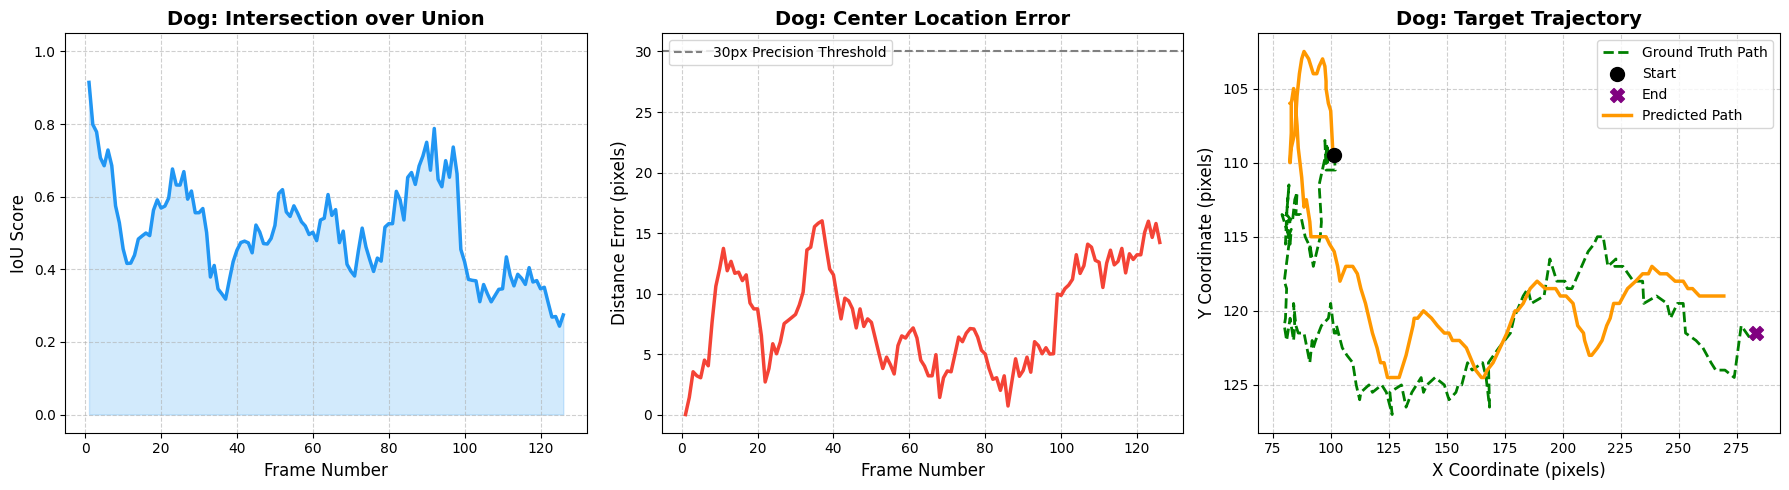

[MountainBike] Starting tracking...
[MountainBike] Processed 100 frames...
[MountainBike] Processed 200 frames...
[MountainBike] Finished! Rendering visual diagnostics...


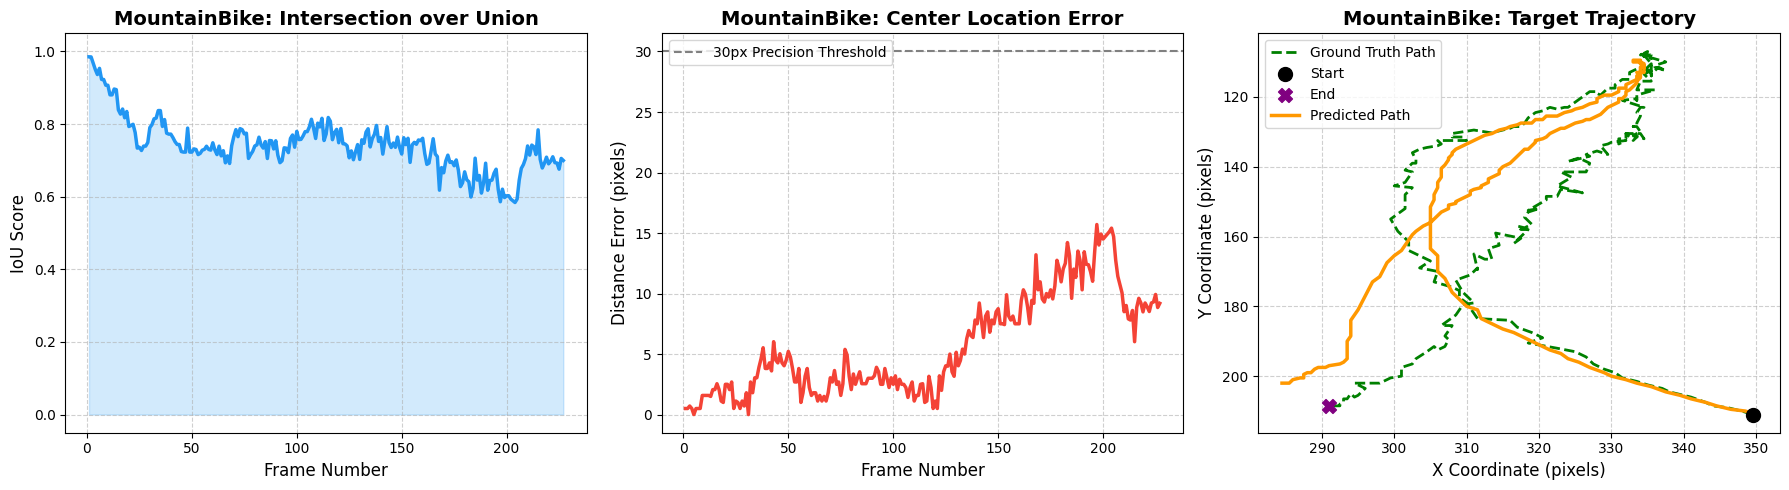

[Jogging] Starting tracking...
[Jogging] Processed 100 frames...
[Jogging] Processed 200 frames...
[Jogging] Processed 300 frames...
[Jogging] Finished! Rendering visual diagnostics...


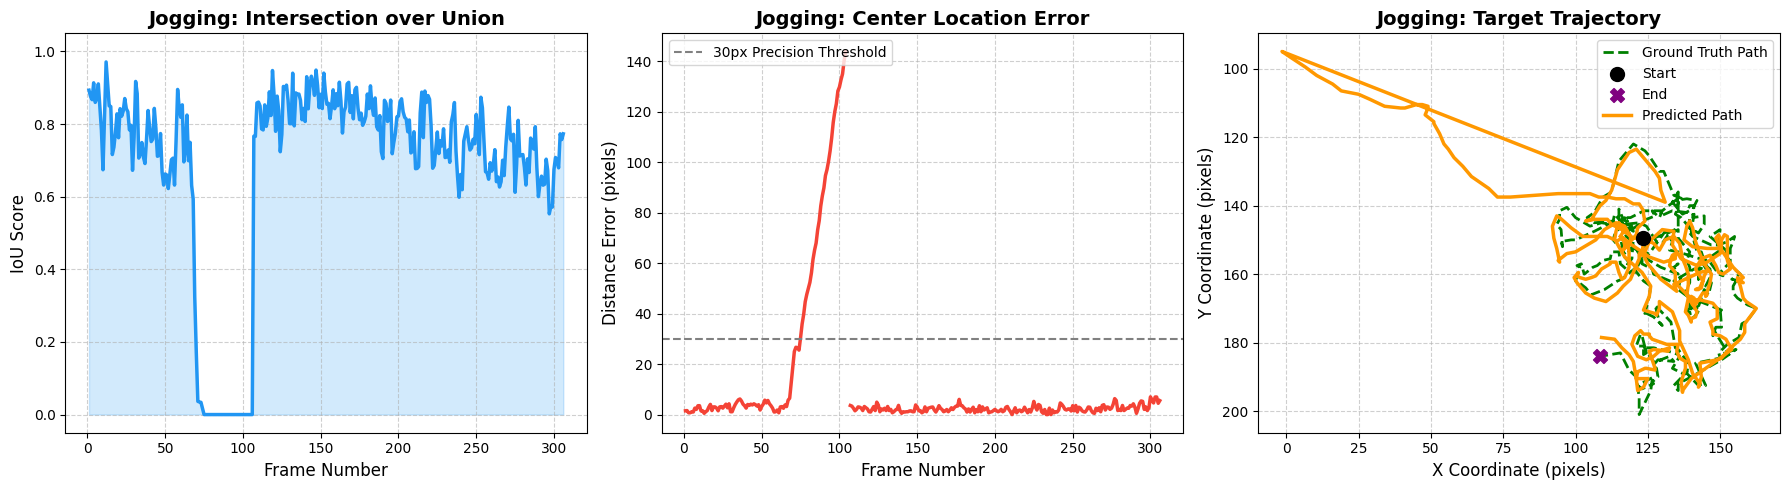

[Car4] Starting tracking...
[Car4] Processed 100 frames...
[Car4] Processed 200 frames...
[Car4] Processed 300 frames...
[Car4] Processed 400 frames...
[Car4] Processed 500 frames...
[Car4] Processed 600 frames...
[Car4] Finished! Rendering visual diagnostics...


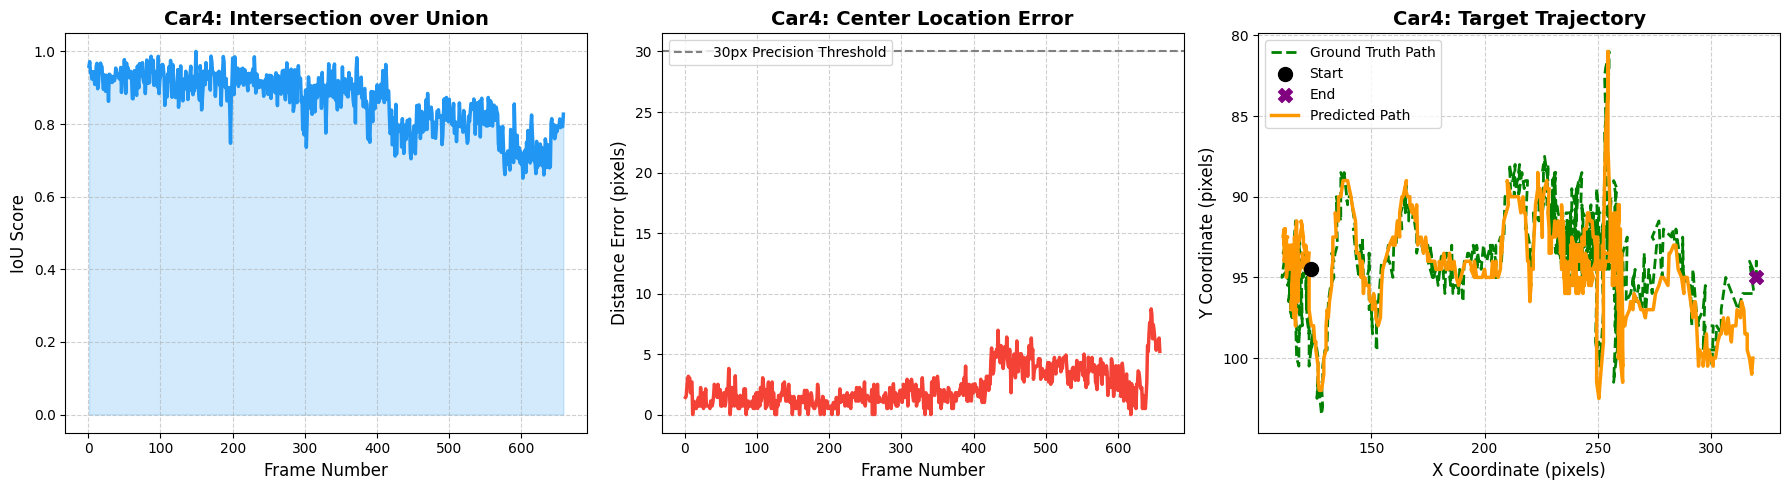

[Skater] Starting tracking...
[Skater] Processed 100 frames...
[Skater] Finished! Rendering visual diagnostics...


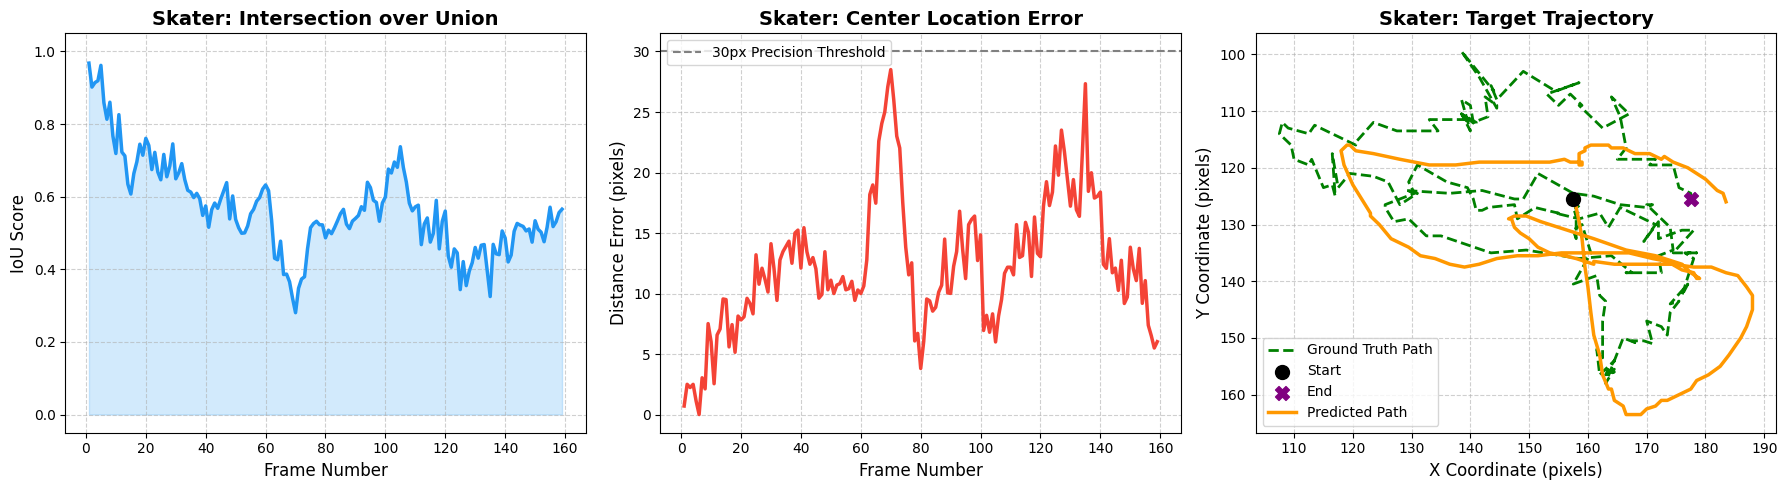


✅ All sequences processed successfully!


In [2]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from IPython.display import display, clear_output

# Ensure Matplotlib renders inside the notebook
%matplotlib inline

# ─────────────────────────────────────────────
# 1. GROUND TRUTH & METRICS ENGINE
# ─────────────────────────────────────────────
def load_otb_gt(gt_path: str) -> dict:
    gt_data = {}
    if not os.path.exists(gt_path): return gt_data
    with open(gt_path, "r") as f:
        for idx, line in enumerate(f.readlines()):
            line = line.replace('\t', ',').strip()
            if not line: continue
            parts = [float(p) for p in line.split(',') if p.strip()]
            if len(parts) >= 4:
                x, y, w, h = parts[:4]
                gt_data[idx + 1] = [x, y, x + w, y + h]
    return gt_data

@dataclass
class NotebookMetrics:
    iou_history: list = field(default_factory=list)
    error_history: list = field(default_factory=list)
    gt_centers: list = field(default_factory=list)
    pred_centers: list = field(default_factory=list)
    threshold_px: float = 30.0 

    def update(self, pred_bbox, gt_bbox=None):
        if gt_bbox is None: 
            return

        gc = self._centre(gt_bbox)
        self.gt_centers.append(gc)

        if pred_bbox is None:
            self.iou_history.append(0.0) 
            self.error_history.append(float('nan')) # NaN prevents lines from connecting during LOST state
            self.pred_centers.append((float('nan'), float('nan')))
            return

        pc = self._centre(pred_bbox)
        iou = self._compute_iou(pred_bbox, gt_bbox)
        dist = np.linalg.norm(np.array(pc) - np.array(gc))

        self.iou_history.append(iou)
        self.error_history.append(dist)
        self.pred_centers.append(pc)

    @staticmethod
    def _compute_iou(b1, b2):
        x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
        x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
        inter = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
        area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
        union = area1 + area2 - inter
        return inter / union if union > 0 else 0.0

    @staticmethod
    def _centre(bbox):
        return ((bbox[0]+bbox[2])/2.0, (bbox[1]+bbox[3])/2.0)

# ─────────────────────────────────────────────
# 2. SEQUENCE LOADER
# ─────────────────────────────────────────────
class OTBSequence:
    def __init__(self, folder_path):
        self.img_dir = os.path.join(folder_path, 'img')
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Could not find 'img' folder inside {folder_path}")
        self.images = sorted(glob.glob(os.path.join(self.img_dir, "*.jpg")))
        if not self.images:
            raise FileNotFoundError(f"No JPG images found in {self.img_dir}")
        self.idx = 0

    def read(self):
        if self.idx >= len(self.images): return False, None
        frame = cv2.imread(self.images[self.idx])
        self.idx += 1
        return True, frame

# ─────────────────────────────────────────────
# 3. YOUR ULTIMATE RESEARCH TRACKER
# ─────────────────────────────────────────────
class ResearchTracker:
    def __init__(self, min_points=4):
        self.min_points = min_points
        self.feature_params = dict(maxCorners=30, qualityLevel=0.03, minDistance=5, blockSize=5)
        self.lk_params = dict(winSize=(21, 21), maxLevel=3, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
        self.state = "TRACKING"
        self.p0 = None
        self.cx, self.cy = 0.0, 0.0 
        self.current_w, self.current_h = 0.0, 0.0
        self.init_w, self.init_h = 0.0, 0.0
        self.bbox = None
        self.base_template = None 
        self.metrics = NotebookMetrics() # Using the new metrics engine

    def initialize_from_gt(self, frame: np.ndarray, gt_bbox: list) -> np.ndarray:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        self.bbox = [int(v) for v in gt_bbox]
        self.init_w = float(self.bbox[2] - self.bbox[0])
        self.init_h = float(self.bbox[3] - self.bbox[1])
        self.current_w, self.current_h = self.init_w, self.init_h
        self.cx = self.bbox[0] + self.init_w / 2.0
        self.cy = self.bbox[1] + self.init_h / 2.0

        x1, y1 = max(0, self.bbox[0]), max(0, self.bbox[1])
        x2, y2 = min(gray.shape[1], self.bbox[2]), min(gray.shape[0], self.bbox[3])
        if x2 > x1 and y2 > y1:
            self.base_template = gray[y1:y2, x1:x2].copy()

        mask = np.zeros_like(gray)
        mask[y1:y2, x1:x2] = 255
        self.p0 = cv2.goodFeaturesToTrack(gray, mask=mask, **self.feature_params)
        self.state = "TRACKING" if self.p0 is not None else "LOST"
        return gray

    def _attempt_recovery(self, gray: np.ndarray) -> bool:
        if self.base_template is None: return False
        th, tw = self.base_template.shape
        h, w = gray.shape
        sx1 = max(0, int(self.cx - tw * 6))
        sy1 = max(0, int(self.cy - th * 3))
        sx2 = min(w, int(self.cx + tw * 6))
        sy2 = min(h, int(self.cy + th * 3))
        
        search_roi = gray[sy1:sy2, sx1:sx2]
        if search_roi.shape[0] < th or search_roi.shape[1] < tw: return False
            
        res = cv2.matchTemplate(search_roi, self.base_template, cv2.TM_CCOEFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        
        if max_val > 0.65: # Tightened threshold as discussed
            self.cx = sx1 + max_loc[0] + tw / 2.0
            self.cy = sy1 + max_loc[1] + th / 2.0
            w_half, h_half = self.current_w / 2.0, self.current_h / 2.0
            self.bbox = [int(self.cx - w_half), int(self.cy - h_half), 
                         int(self.cx + w_half), int(self.cy + h_half)]
            return True
        return False

    def track(self, old_gray, frame, gt_bbox=None):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if self.p0 is None or len(self.p0) < self.min_points or self.state == "LOST":
            if self._attempt_recovery(gray):
                self._reinitialize(gray)
                self.state = "TRACKING"
            else:
                self.state = "LOST"
                self.metrics.update(None, gt_bbox)
                return gray, frame

        p1, st, _ = cv2.calcOpticalFlowPyrLK(old_gray, gray, self.p0, None, **self.lk_params)
        p0_back, _, _ = cv2.calcOpticalFlowPyrLK(gray, old_gray, p1, None, **self.lk_params)

        fb_error = np.linalg.norm(self.p0 - p0_back, axis=2).flatten()
        valid = (st.flatten() == 1) & (fb_error < 2.0)
        
        surv_new = p1[valid].reshape(-1, 2)
        surv_old = self.p0[valid].reshape(-1, 2)

        if len(surv_new) < self.min_points:
            self.state = "LOST"
            self.metrics.update(None, gt_bbox)
            return gray, frame

        margin = 20 
        spatial_good = (surv_new[:,0] >= self.bbox[0] - margin) & \
                       (surv_new[:,0] <= self.bbox[2] + margin) & \
                       (surv_new[:,1] >= self.bbox[1] - margin) & \
                       (surv_new[:,1] <= self.bbox[3] + margin)
        
        surv_new = surv_new[spatial_good]
        surv_old = surv_old[spatial_good]

        if len(surv_new) < self.min_points:
            self.state = "LOST"
            self.metrics.update(None, gt_bbox)
            return gray, frame

        motion = surv_new - surv_old
        dists = np.linalg.norm(motion, axis=1)
        med = np.median(dists)
        mad = np.median(np.abs(dists - med))
        
        if mad < 1e-3: mad_good = np.ones_like(dists, dtype=bool) 
        else: mad_good = np.abs(dists - med) < (3.0 * mad)
        
        t_new = surv_new[mad_good]
        t_old = surv_old[mad_good]

        if len(t_new) >= self.min_points:
            dx = np.median(t_new[:, 0] - t_old[:, 0])
            dy = np.median(t_new[:, 1] - t_old[:, 1])
            self.cx += dx
            self.cy += dy

            center_new = np.median(t_new, axis=0)
            center_old = np.median(t_old, axis=0)
            dist_new = np.linalg.norm(t_new - center_new, axis=1)
            dist_old = np.linalg.norm(t_old - center_old, axis=1)
            
            valid_scale = dist_old > 2.0 
            if np.any(valid_scale):
                scale_factor = np.median(dist_new[valid_scale] / dist_old[valid_scale])
                scale_factor = np.clip(scale_factor, 0.98, 1.02) 
                self.current_w *= scale_factor
                self.current_h *= scale_factor
            
            self.current_w = np.clip(self.current_w, self.init_w * 0.5, self.init_w * 1.5)
            self.current_h = np.clip(self.current_h, self.init_h * 0.5, self.init_h * 1.5)

            w_half, h_half = self.current_w / 2.0, self.current_h / 2.0
            self.bbox = [int(self.cx - w_half), int(self.cy - h_half), 
                         int(self.cx + w_half), int(self.cy + h_half)]
            self.state = "TRACKING"
        else:
            self.state = "WEAK_TRACKING"

        self.p0 = t_new.reshape(-1, 1, 2)
        if len(t_new) < 15: self._reinitialize(gray)

        self.metrics.update(self.bbox if self.state != "LOST" else None, gt_bbox)
        return gray, frame

    def _reinitialize(self, gray):
        h_img, w_img = gray.shape
        pad_x, pad_y = int(self.current_w * 0.1), int(self.current_h * 0.1)
        x1, y1 = max(0, self.bbox[0] + pad_x), max(0, self.bbox[1] + pad_y)
        x2, y2 = min(w_img, self.bbox[2] - pad_x), min(h_img, self.bbox[3] - pad_y)
        
        if x2 > x1 and y2 > y1:
            mask = np.zeros_like(gray)
            mask[y1:y2, x1:x2] = 255
            if self.p0 is not None:
                for pt in self.p0: cv2.circle(mask, (int(pt[0][0]), int(pt[0][1])), 5, 0, -1)
            new_pts = cv2.goodFeaturesToTrack(gray, mask=mask, **self.feature_params)
            if new_pts is not None:
                self.p0 = np.vstack((self.p0, new_pts))

# ─────────────────────────────────────────────
# 4. PLOTTING & EXECUTION ENGINE
# ─────────────────────────────────────────────
def plot_sequence_diagnostics(metrics, seq_name):
    frames = np.arange(1, len(metrics.iou_history) + 1)
    iou = np.array(metrics.iou_history)
    error = np.array(metrics.error_history)
    gt_c = np.array(metrics.gt_centers)
    pr_c = np.array(metrics.pred_centers)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: IoU
    axes[0].plot(frames, iou, color='#2196F3', linewidth=2.5)
    axes[0].fill_between(frames, iou, alpha=0.2, color='#2196F3')
    axes[0].set_title(f'{seq_name}: Intersection over Union', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Frame Number', fontsize=12)
    axes[0].set_ylabel('IoU Score', fontsize=12)
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Center Error
    axes[1].plot(frames, error, color='#F44336', linewidth=2.5)
    axes[1].axhline(30, color='gray', linestyle='--', label='30px Precision Threshold')
    axes[1].set_title(f'{seq_name}: Center Location Error', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Frame Number', fontsize=12)
    axes[1].set_ylabel('Distance Error (pixels)', fontsize=12)
    axes[1].legend(loc='upper left')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Plot 3: 2D Trajectory
    if len(gt_c) > 0:
        axes[2].plot(gt_c[:, 0], gt_c[:, 1], 'g--', label='Ground Truth Path', linewidth=2)
        axes[2].scatter(gt_c[0, 0], gt_c[0, 1], color='black', marker='o', s=100, label='Start', zorder=5)
        axes[2].scatter(gt_c[-1, 0], gt_c[-1, 1], color='purple', marker='X', s=100, label='End', zorder=5)
    
    # Filter out NaNs for plotting the predicted path cleanly
    valid_pr = ~np.isnan(pr_c[:, 0])
    axes[2].plot(pr_c[valid_pr, 0], pr_c[valid_pr, 1], color='#FF9800', label='Predicted Path', linewidth=2.5)
    
    axes[2].set_title(f'{seq_name}: Target Trajectory', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('X Coordinate (pixels)', fontsize=12)
    axes[2].set_ylabel('Y Coordinate (pixels)', fontsize=12)
    axes[2].legend(loc='best')
    axes[2].invert_yaxis() 
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    # Save a high-res copy for the paper just in case!
    plt.savefig(f'notebook_graphs_{seq_name}.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

def process_sequence_in_notebook(seq_name, seq_folder):
    gt_path = os.path.join(seq_folder, 'groundtruth_rect.txt')
    if not os.path.exists(gt_path): gt_path = os.path.join(seq_folder, 'groundtruth_rect.1.txt')

    print(f"[{seq_name}] Starting tracking...")
    gt_data = load_otb_gt(gt_path)
    
    stream = OTBSequence(seq_folder)
    ret, frame = stream.read()
    if not ret: return
    
    tracker = ResearchTracker()
    old_gray = tracker.initialize_from_gt(frame, gt_data.get(1))

    frame_idx = 1
    while True:
        ret, frame = stream.read()
        if not ret: break
        frame_idx += 1
        
        old_gray, _ = tracker.track(old_gray, frame, gt_bbox=gt_data.get(frame_idx))
        
        # Show progress without flooding output
        if frame_idx % 100 == 0:
            print(f"[{seq_name}] Processed {frame_idx} frames...")

    print(f"[{seq_name}] Finished! Rendering visual diagnostics...")
    plot_sequence_diagnostics(tracker.metrics, seq_name)

# ─────────────────────────────────────────────
# 5. RUN ALL SEQUENCES
# ─────────────────────────────────────────────
if __name__ == "__main__":
    otb_sequences = {
        "Dog": "Dog", 
        "MountainBike": "MountainBike", 
        "Jogging": "Jogging", 
        "Car4": "Car4", 
        "Skater": "Skater"
    }
    
    print("Initializing Multi-Sequence Batch Run for Notebook...")
    for name, folder in otb_sequences.items():
        if os.path.exists(folder):
            process_sequence_in_notebook(name, folder)
        else:
            print(f"[Warning] Could not find folder '{folder}'. Skipping...")
    
    print("\n✅ All sequences processed successfully!")